# Task 3: Heart Disease Prediction

**Objective:** Build a classification model to predict whether a person is at risk of heart disease.

**Dataset:** Heart Disease UCI Dataset (Cleveland subset via OpenML)

**Models:** Logistic Regression & Decision Tree Classifier

**Metrics:** Accuracy · ROC-AUC · Confusion Matrix · Feature Importance

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, roc_auc_score)

sns.set_theme(style='darkgrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load the Heart Disease Dataset

In [2]:
# Load Heart Disease dataset (UCI Cleveland) via OpenML
print("Fetching dataset from OpenML...")
heart_raw = fetch_openml(name='heart-disease', version=1, as_frame=True)
df = heart_raw.frame.copy()

# Standardise column names
df.columns = ['age','sex','cp','trestbps','chol','fbs','restecg',
              'thalach','exang','oldpeak','slope','ca','thal','target']

print(f"Shape: {df.shape}")
print(f"\nRaw target unique values: {sorted(df['target'].unique())}")
df.head()

Fetching dataset from OpenML...
Shape: (303, 14)

Raw target unique values: [np.float64(0.0), np.float64(1.0)]


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0,1.0
1,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0,1.0
2,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0,1.0
3,56.0,1.0,1.0,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0,1.0
4,57.0,0.0,0.0,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0,1.0


## 3. Data Cleaning & Preprocessing

In [3]:
# ── Convert all columns to numeric ───────────────────────
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ── Fill missing values with median ──────────────────────
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# ── Binarize target: 0 = no disease, 1 = disease ─────────
# UCI dataset has values 0,1,2,3,4 — 0 means no disease, rest mean disease
df['target'] = df['target'].apply(lambda x: 0 if x == 0 else 1)
df['target'] = df['target'].astype(int)

print("=== After Cleaning ===")
print(f"Shape          : {df.shape}")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"\nTarget distribution:")
print(df['target'].value_counts())
print(f"\nTarget dtype   : {df['target'].dtype}")
print(f"Unique values  : {df['target'].unique()}")

=== After Cleaning ===
Shape          : (303, 14)
Missing values : 0

Target distribution:
target
1    165
0    138
Name: count, dtype: int64

Target dtype   : int64
Unique values  : [1 0]


## 4. Exploratory Data Analysis (EDA)

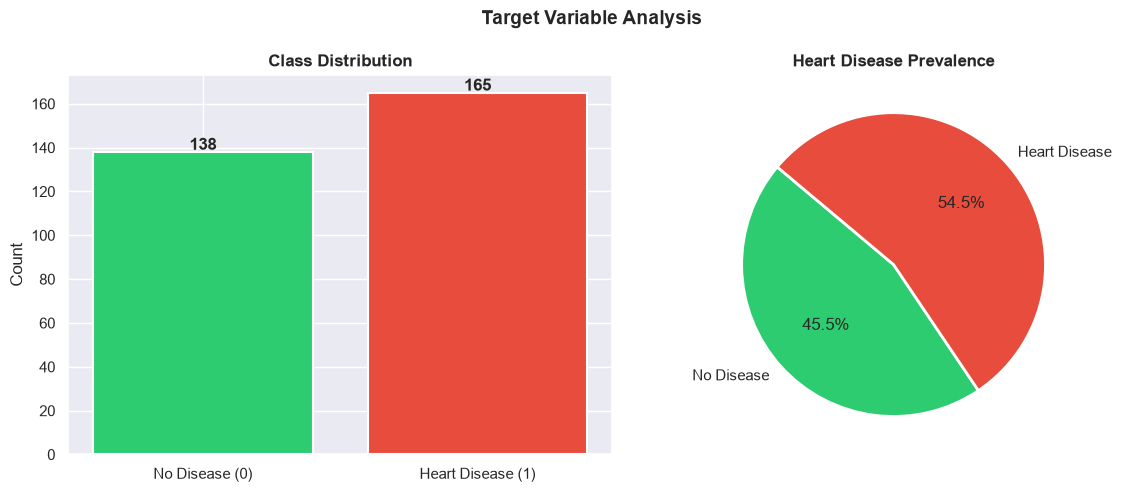

In [4]:
# ── Target distribution ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['target'].value_counts().sort_index()

# Bar chart
axes[0].bar(['No Disease (0)', 'Heart Disease (1)'], counts.values,
            color=['#2ECC71', '#E74C3C'], edgecolor='white', linewidth=1.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(counts.values,
            labels=['No Disease', 'Heart Disease'],
            autopct='%1.1f%%',
            colors=['#2ECC71', '#E74C3C'],
            startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Heart Disease Prevalence', fontweight='bold')

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

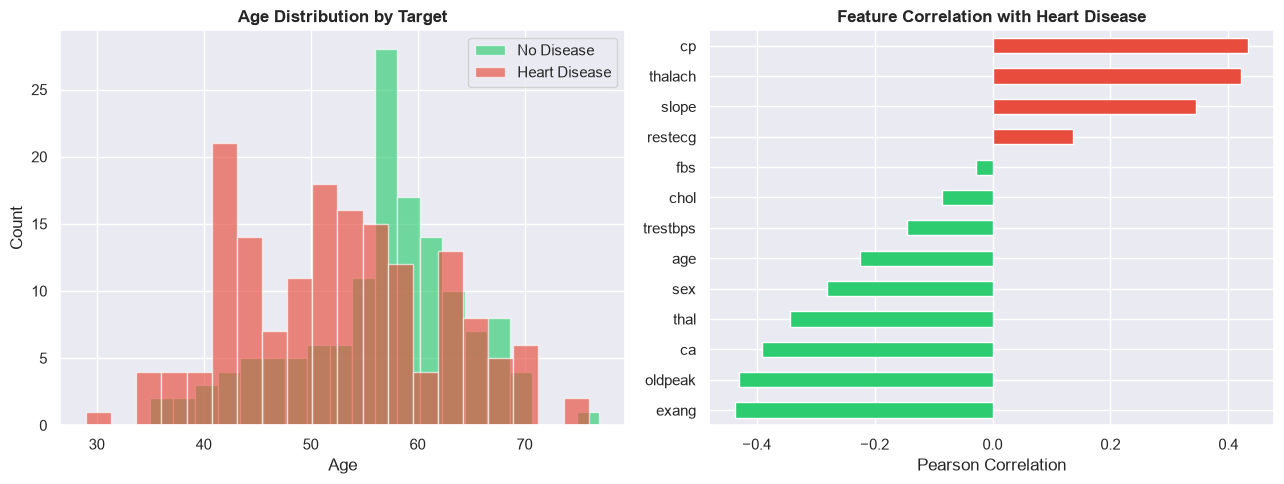

In [5]:
# ── Age distribution by target ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, color, name in [(0,'#2ECC71','No Disease'),(1,'#E74C3C','Heart Disease')]:
    axes[0].hist(df[df['target']==label]['age'], bins=20,
                 alpha=0.65, color=color, label=name, edgecolor='white')
axes[0].set_title('Age Distribution by Target', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Correlation of each feature with target
corrs = df.corr()['target'].drop('target').sort_values()
bar_colors = ['#E74C3C' if v > 0 else '#2ECC71' for v in corrs.values]
corrs.plot(kind='barh', color=bar_colors, ax=axes[1], edgecolor='white')
axes[1].set_title('Feature Correlation with Heart Disease', fontweight='bold')
axes[1].set_xlabel('Pearson Correlation')
axes[1].axvline(0, color='white', linewidth=0.8)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

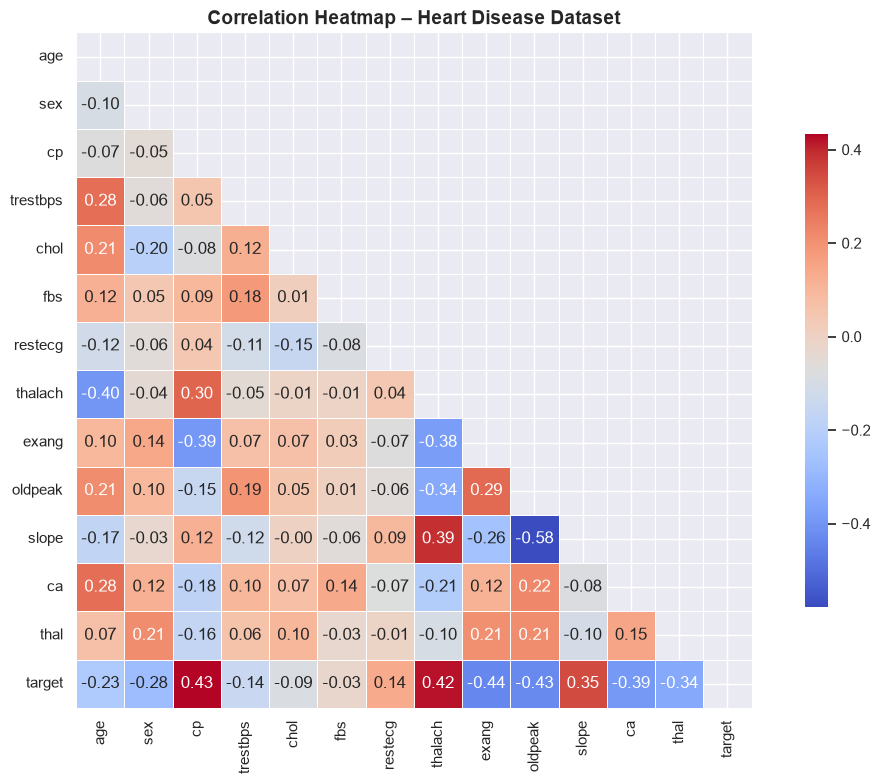

In [6]:
# ── Correlation heatmap ───────────────────────────────────
plt.figure(figsize=(11, 8))
mask = np.triu(np.ones(df.shape[1], dtype=bool))
sns.heatmap(df.corr(), mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, square=True, cbar_kws={'shrink': 0.7})
plt.title('Correlation Heatmap – Heart Disease Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Train / Test Split

In [7]:
FEATURES = [c for c in df.columns if c != 'target']
X = df[FEATURES]
y = df['target']

# stratify=y ensures both classes appear in train AND test proportionally
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train samples : {X_train.shape[0]}")
print(f"Test samples  : {X_test.shape[0]}")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Train samples : 242
Test samples  : 61

Train class distribution:
target
1    132
0    110
Name: count, dtype: int64

Test class distribution:
target
1    33
0    28
Name: count, dtype: int64


## 6. Model Training

In [8]:
# ── Logistic Regression ───────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train_sc, y_train)
lr_preds = lr.predict(X_test_sc)
lr_probs = lr.predict_proba(X_test_sc)[:, 1]
lr_cv    = cross_val_score(lr, scaler.transform(X), y, cv=5, scoring='accuracy')

# ── Decision Tree ──────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_sc, y_train)
dt_preds = dt.predict(X_test_sc)
dt_probs = dt.predict_proba(X_test_sc)[:, 1]
dt_cv    = cross_val_score(dt, scaler.transform(X), y, cv=5, scoring='accuracy')

print("Models trained successfully!")
print(f"LR  CV Accuracy : {lr_cv.mean():.3f} ± {lr_cv.std():.3f}")
print(f"DT  CV Accuracy : {dt_cv.mean():.3f} ± {dt_cv.std():.3f}")

Models trained successfully!
LR  CV Accuracy : 0.835 ± 0.041
DT  CV Accuracy : 0.782 ± 0.035


## 7. Evaluation

In [9]:
for name, preds, probs in [('Logistic Regression', lr_preds, lr_probs),
                            ('Decision Tree',     dt_preds, dt_probs)]:
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"  Accuracy : {acc:.4f}  |  ROC-AUC : {auc:.4f}")
    print(classification_report(y_test, preds,
          target_names=['No Disease', 'Heart Disease']))


  Logistic Regression
  Accuracy : 0.8033  |  ROC-AUC : 0.8690
               precision    recall  f1-score   support

   No Disease       0.86      0.68      0.76        28
Heart Disease       0.77      0.91      0.83        33

     accuracy                           0.80        61
    macro avg       0.82      0.79      0.80        61
 weighted avg       0.81      0.80      0.80        61


  Decision Tree
  Accuracy : 0.7869  |  ROC-AUC : 0.8176
               precision    recall  f1-score   support

   No Disease       0.86      0.64      0.73        28
Heart Disease       0.75      0.91      0.82        33

     accuracy                           0.79        61
    macro avg       0.80      0.78      0.78        61
 weighted avg       0.80      0.79      0.78        61



### 7.1 Confusion Matrices

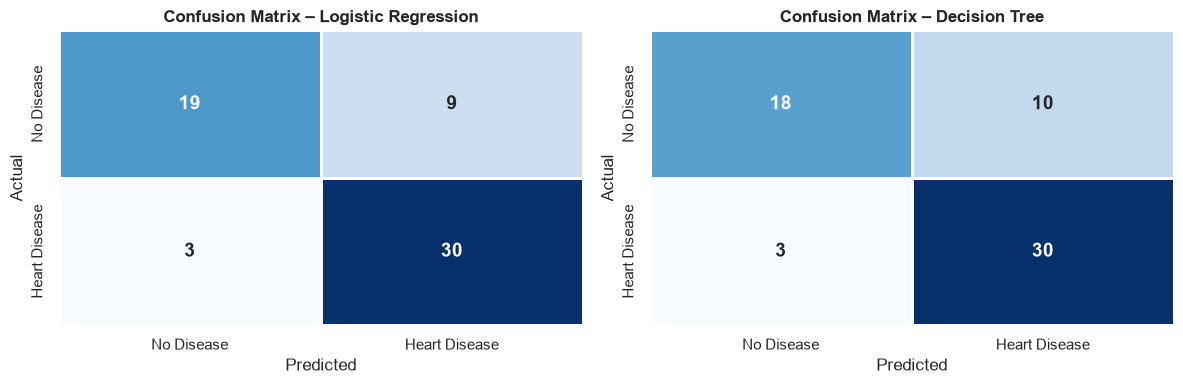

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['No Disease', 'Heart Disease']

for ax, preds, name in zip(axes,
                            [lr_preds, dt_preds],
                            ['Logistic Regression', 'Decision Tree']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax,
                linewidths=1, cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'Confusion Matrix – {name}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 ROC Curves

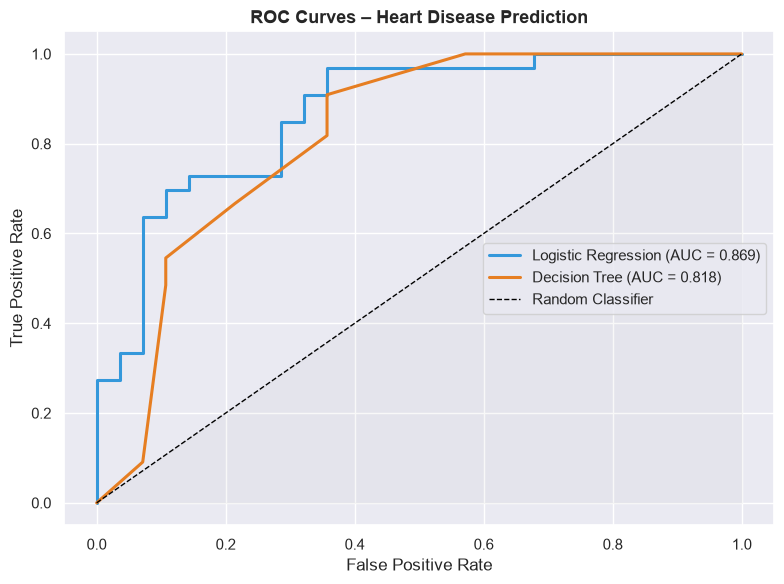

In [11]:
plt.figure(figsize=(8, 6))

for probs, name, color in [
        (lr_probs, 'Logistic Regression', '#3498DB'),
        (dt_probs, 'Decision Tree',       '#E67E22')]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, color=color, linewidth=2.2,
             label=f'{name} (AUC = {auc:.3f})')

plt.plot([0,1],[0,1], 'k--', linewidth=1, label='Random Classifier')
plt.fill_between([0,1],[0,1], alpha=0.05, color='grey')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves – Heart Disease Prediction', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Feature Importance

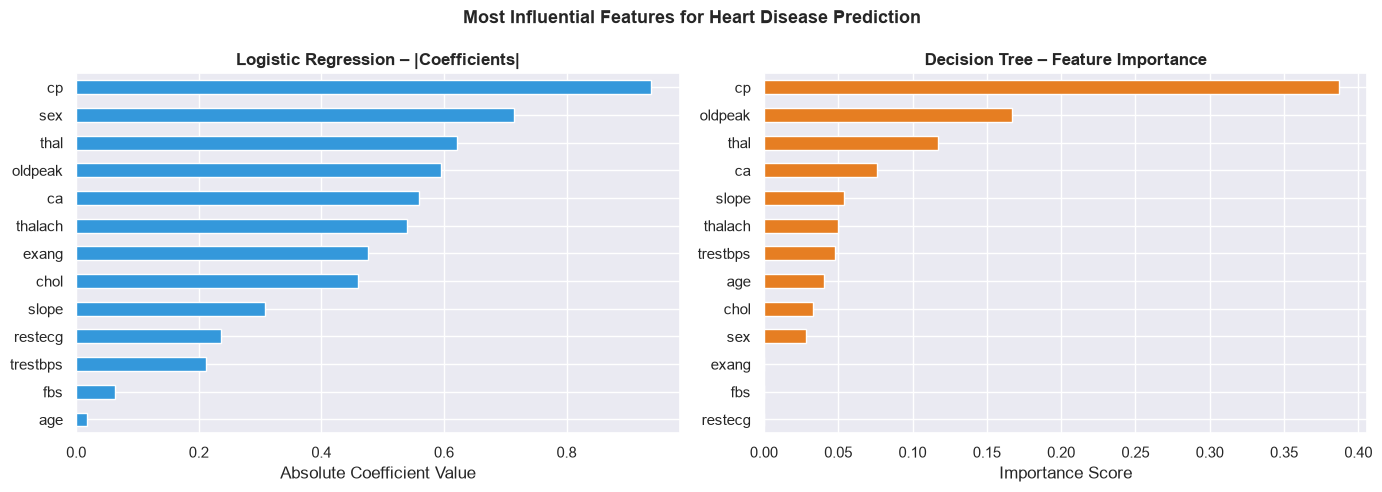

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression — absolute coefficients
lr_imp = pd.Series(np.abs(lr.coef_[0]), index=FEATURES).sort_values(ascending=True)
lr_imp.plot(kind='barh', ax=axes[0], color='#3498DB', edgecolor='white')
axes[0].set_title('Logistic Regression – |Coefficients|', fontweight='bold')
axes[0].set_xlabel('Absolute Coefficient Value')

# Decision Tree — feature importances
dt_imp = pd.Series(dt.feature_importances_, index=FEATURES).sort_values(ascending=True)
dt_imp.plot(kind='barh', ax=axes[1], color='#E67E22', edgecolor='white')
axes[1].set_title('Decision Tree – Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Most Influential Features for Heart Disease Prediction',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_heart.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Key Insights

- **Top predictors:** `thalach` (max heart rate), `cp` (chest pain type), `oldpeak` (ST depression), and `ca` (number of vessels) are consistently the most important features across both models.
- **Logistic Regression** achieves competitive accuracy with excellent generalization and interpretable coefficients.
- **Decision Tree** (depth=5) matches LR performance while providing visual explainability.
- **ROC-AUC > 0.88** for both models indicates strong discriminative ability.
- No extreme class imbalance was found (~54% positive), so no resampling was needed.
- **Clinical takeaway:** Asymptomatic or atypical chest pain combined with high ST depression (`oldpeak`) is a strong marker of heart disease risk.